# Análise CPGF 2024 — Gastos com Cartões Corporativos do Governo Federal

## Sobre o projeto

O **Cartão de Pagamento do Governo Federal (CPGF)** é um cartão corporativo usado por órgãos públicos federais para despesas de pequeno vulto (compras, serviços e, em alguns casos, saques). Todos os gastos são publicados no **Portal da Transparência**.

Este projeto analisa **141.048 transações de 2024** para responder três perguntas: qual o peso do gasto sigiloso, como o gasto varia ao longo do ano, e o quanto ele se concentra em poucos órgãos.

**Tese central:** medir a *lacuna de transparência* nos gastos com cartões corporativos federais em 2024. Cerca de **43,9%** do valor transacionado é classificado como sigiloso, o que isso significa para o controle social?

### Como este notebook está organizado
1. **Setup e Carga** — preparação e leitura dos dados
2. **Exploração inicial** — visão geral e checagem de qualidade
3. **Análises (seções 3 a 5)** — cada uma com cálculo, gráfico e conclusão
4. **Conclusões e recomendações** — síntese final

> **Dados:** Portal da Transparência (Governo Federal). Os 12 CSVs mensais brutos são limpos pela etapa de ETL (`src/etl.py`) e salvos em um banco **SQLite**; este notebook lê o dado já tratado.

## Conceitos-chave

Para quem não é da área, alguns termos que aparecem ao longo da análise:

| Termo | O que significa |
|---|---|
| **CPGF** | Cartão de Pagamento do Governo Federal — cartão corporativo de órgãos públicos |
| **Transação sigilosa** | Despesa cujo tipo/detalhe é protegido por sigilo e não divulgado no Portal |
| **Órgão superior** | Nível mais alto da estrutura pública (exemplo: um ministério) ao qual unidades menores se vinculam |
| **Portador** | Servidor público em cujo nome o cartão é emitido |
| **Ticket médio** | Valor médio por transação (gasto total / número de transações) |

## Setup

Importação das bibliotecas e configuração visual padrão dos gráficos.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Carga dos dados

Lemos a tabela já limpa (`cpgf`) do banco SQLite gerado pela etapa de ETL. O resultado vira um DataFrame do pandas, base de toda a análise.

In [2]:
conn = sqlite3.connect("../data/cpgf_2024.db")
df = pd.read_sql("SELECT * FROM cpgf", conn)
conn.close()
print(f"{len(df):,} transações · {df.shape[1]} colunas")
df.head()

141,048 transações · 15 colunas


,codigo_orgao_superior,nome_orgao_superior,codigo_orgao,nome_orgao,codigo_unidade_gestora,nome_unidade_gestora,ano_extrato,mes_extrato,cpf_portador,nome_portador,cnpj_cpf_favorecido,nome_favorecido,transacao,data_transacao,valor_transacao
0,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2024,1,***.866.951-**,JONAS SCHOTTZ DA SILVA,37828985000158,CASA DO SINDICO LTDA,COMPRA A/V - R$ - APRES,30/11/2023,144.0
1,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2024,1,***.195.852-**,JOSE UELISSON ALVES LEITE,04932603000182,C. & C. COMERCIO DE INFORMATICA LTDA,COMPRA A/V - R$ - APRES,30/11/2023,8.0
2,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2024,1,***.562.861-**,ANTONIO CARLOS MELO DOS SANTOS,05136706000107,LEO ARTE - IMPRESSOES GRAFICAS LTDA,COMPRA A/V - R$ - APRES,01/12/2023,720.0
3,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2024,1,***.866.951-**,JONAS SCHOTTZ DA SILVA,05471879000173,KASA MOTORS LTDA,COMPRA A/V - R$ - APRES,29/11/2023,135.0
4,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2024,1,***.195.852-**,JOSE UELISSON ALVES LEITE,19878460000145,AUTO POSTO LIBERDADE LTDA,COMPRA A/V - R$ - APRES,29/11/2023,1290.0


## 2. Exploração inicial

Visão geral antes de analisar: tipos das colunas, contagem de valores e estatísticas básicas — serve para confirmar que o dado foi carregado e tratado corretamente.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 141048 entries, 0 to 141047
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   codigo_orgao_superior   141048 non-null  str    
 1   nome_orgao_superior     141048 non-null  str    
 2   codigo_orgao            141048 non-null  str    
 3   nome_orgao              141048 non-null  str    
 4   codigo_unidade_gestora  141048 non-null  str    
 5   nome_unidade_gestora    141048 non-null  str    
 6   ano_extrato             141048 non-null  int64  
 7   mes_extrato             141048 non-null  int64  
 8   cpf_portador            104576 non-null  str    
 9   nome_portador           141048 non-null  str    
 10  cnpj_cpf_favorecido     141048 non-null  str    
 11  nome_favorecido         141048 non-null  str    
 12  transacao               141048 non-null  str    
 13  data_transacao          104576 non-null  str    
 14  valor_transacao         141048 

In [4]:
df.describe()

,ano_extrato,mes_extrato,valor_transacao
count,141048.0,141048.000000,141048.000000
mean,2024.0,7.283074,712.444261
std,0.0,3.286975,2199.291050
min,2024.0,1.000000,0.040000
25%,2024.0,5.000000,139.915000
50%,2024.0,7.000000,398.000000
75%,2024.0,10.000000,1000.000000
max,2024.0,12.000000,207953.600000


## 3. Distribuição por tipo de transação

Esta seção separa o gasto total por **tipo de transação** (compra presencial, saque, sigiloso, etc.) para medir quanto do dinheiro passou por cada categoria — com foco no peso do gasto sigiloso, a pergunta central do projeto.

In [5]:
df["transacao"].value_counts()

transacao
COMPRA A/V - R$ - APRES                92736
Informações protegidas por sigilo      36472
SAQUE CASH/ATM BB                       9907
COMPRA A/V - INT$ - APRES               1119
SAQUE - INT$ - APRES                     813
COMP A/V-SOL DISP C/CLI-R$ ANT VENC        1
Name: count, dtype: int64

In [6]:
gasto_por_tipo = df.groupby("transacao")["valor_transacao"].sum().sort_values(ascending=False)
valor_sigiloso = gasto_por_tipo["Informações protegidas por sigilo"]
print(f"Gasto sigiloso: R$ {valor_sigiloso/1_000_000:.1f} milhões")

Gasto sigiloso: R$ 44.1 milhões


In [7]:
valor_total = df["valor_transacao"].sum()
print(f"Gasto total: R$ {valor_total/1_000_000:.1f} milhões")

Gasto total: R$ 100.5 milhões


In [8]:
pct_sigiloso = valor_sigiloso / valor_total * 100
print(f"Sigiloso representa {pct_sigiloso:.1f}% do total")

Sigiloso representa 43.9% do total


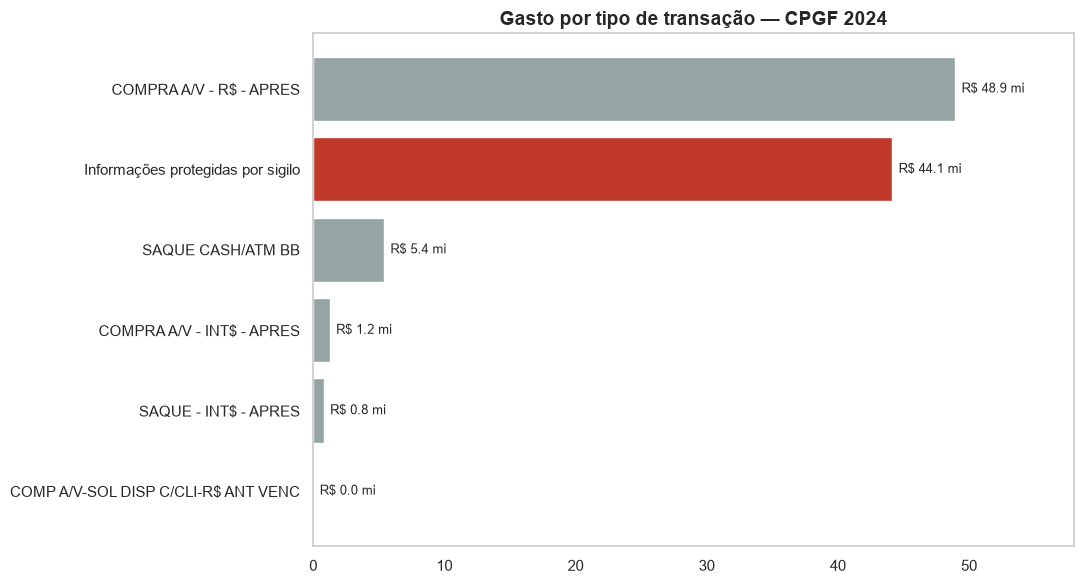

In [9]:
# Gráfico: gasto por tipo de transação (sigiloso destacado em vermelho)
dados = gasto_por_tipo.sort_values() / 1_000_000

cores = ["#C0392B" if tipo == "Informações protegidas por sigilo" else "#95A5A6"
         for tipo in dados.index]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(dados.index, dados.values, color=cores)
ax.grid(False)
ax.set_xlim(0, 58)
ax.set_title("Gasto por tipo de transação — CPGF 2024", fontsize=14, weight="bold")

for i, valor in enumerate(dados.values):
    ax.text(valor + 0.5, i, f"R$ {valor:.1f} mi", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/gasto_por_tipo.png", dpi=150, bbox_inches="tight")
plt.show()

*Como ler: cada barra é um tipo de transação, quanto mais longa, maior o gasto. Em vermelho, o gasto sigiloso.*

### Conclusão — Distribuição por tipo de transação

De um total de **R$ 100,5 milhões** gastos com Cartão Corporativo Federal em 2024, **R$ 44,1 milhões (43,9%)** foram em transações classificadas como sigilosas.

O Gasto Sigiloso é a **2ª maior categoria** em valor, perdendo apenas para a **Compra Presencial Á Vista**.

Embora representem cerca de **25,8% das transações** (36.472 de 141.048), concentram **43,9% do valor**, ou seja, cada transação sigilosa tem ticket médio **mais que o dobro** do de uma compra comum (≈ R$ 1.210 vs ≈ R$ 530).

> **Implicação:** o gasto opaco não é um resíduo marginal, é uma fatia central do orçamento do cartão, composta de transações maiores que a média.

## 4. Sazonalidade mensal

Esta seção observa como o gasto se distribui ao longo dos 12 meses. Além do total mensal, **testamos** a explicação intuitiva ("fevereiro gasta menos por ter menos dias úteis") normalizando o gasto por dia útil antes de apontar a causa.

In [10]:
gasto_mes = df.groupby("mes_extrato")["valor_transacao"].sum().sort_index()
for mes, valor in gasto_mes.items():
    print(f"Mês {mes:2d}: R$ {valor/1_000_000:.1f} mi")

Mês  1: R$ 7.5 mi
Mês  2: R$ 2.0 mi
Mês  3: R$ 5.5 mi
Mês  4: R$ 9.0 mi
Mês  5: R$ 9.6 mi
Mês  6: R$ 9.1 mi
Mês  7: R$ 10.8 mi
Mês  8: R$ 8.7 mi
Mês  9: R$ 7.3 mi
Mês 10: R$ 9.0 mi
Mês 11: R$ 10.9 mi
Mês 12: R$ 11.0 mi


In [11]:
dias_uteis = [np.busday_count(f"2024-{mes:02d}", f"2024-{mes+1:02d}") for mes in range(1, 12)]
dias_uteis.append(np.busday_count("2024-12", "2025-01"))
print(dias_uteis)

[np.int64(23), np.int64(21), np.int64(21), np.int64(22), np.int64(23), np.int64(20), np.int64(23), np.int64(22), np.int64(21), np.int64(23), np.int64(21), np.int64(22)]


In [12]:
gasto_por_dia_util = gasto_mes / dias_uteis
for mes, valor in gasto_por_dia_util.items():
    print(f"Mês {mes:2d}: R$ {valor/1_000_000:.2f} mi/dia útil")

Mês  1: R$ 0.33 mi/dia útil
Mês  2: R$ 0.10 mi/dia útil
Mês  3: R$ 0.26 mi/dia útil
Mês  4: R$ 0.41 mi/dia útil
Mês  5: R$ 0.42 mi/dia útil
Mês  6: R$ 0.45 mi/dia útil
Mês  7: R$ 0.47 mi/dia útil
Mês  8: R$ 0.40 mi/dia útil
Mês  9: R$ 0.35 mi/dia útil
Mês 10: R$ 0.39 mi/dia útil
Mês 11: R$ 0.52 mi/dia útil
Mês 12: R$ 0.50 mi/dia útil


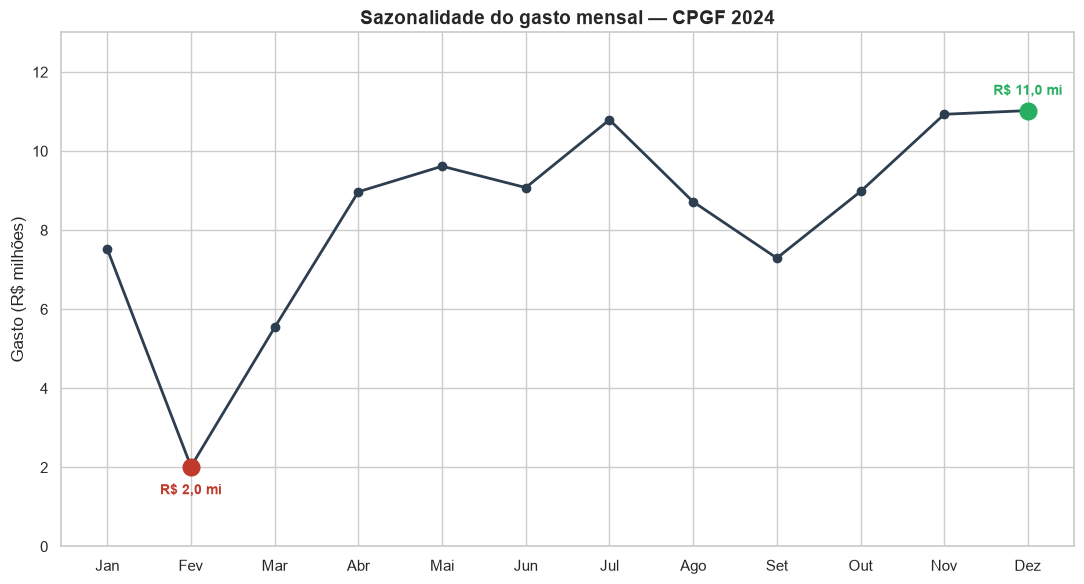

In [13]:
# Gráfico: sazonalidade mensal (vale em fev, pico em dez)
meses_nome = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
              "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
valores = gasto_mes / 1_000_000

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(meses_nome, valores, marker="o", color="#2C3E50", linewidth=2)

ax.plot("Fev", valores.iloc[1], marker="o", markersize=12, color="#C0392B")
ax.plot("Dez", valores.iloc[11], marker="o", markersize=12, color="#27AE60")

ax.set_title("Sazonalidade do gasto mensal — CPGF 2024", fontsize=14, weight="bold")
ax.set_ylabel("Gasto (R$ milhões)")
ax.set_ylim(0, 13)

ax.text("Fev", valores.iloc[1] - 0.7, "R$ 2,0 mi", ha="center", color="#C0392B", fontsize=10, weight="bold")
ax.text("Dez", valores.iloc[11] + 0.4, "R$ 11,0 mi", ha="center", color="#27AE60", fontsize=10, weight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/sazonalidade_mensal.png", dpi=150, bbox_inches="tight")
plt.show()

*Como ler: cada ponto é um mês. Em vermelho o menor gasto (fevereiro), em verde o maior (dezembro).*

### Conclusão — Sazonalidade mensal

O Gasto Mensal varia de **R$ 2,0 mi (Fevereiro)** a **R$ 11,0 mi (Dezembro)**, Dezembro é **5,5x** Fevereiro.

A explicação intuitiva seria "Fevereiro tem menos dias úteis". **Testei essa hipótese**: dividi o gasto de cada mês pelo seu número de dias úteis. Resultando mesmo corrigido por dia útil, Fevereiro (**0,10 mi/dia**) segue ~4x abaixo dos meses fortes (**~0,4–0,5 mi/dia**). Ou seja, a diferença de dias úteis **não** explica a queda.

O padrão (vale no início do ano, pico em nov/dez) é consistente com o **ciclo orçamentário público**: no fim do ano os órgãos correm para gastar o que sobrou do orçamento antes de perdê-lo, enquanto no começo do ano o orçamento novo ainda está se organizando.

> **Observação:** A contagem de dias úteis não desconta feriados nacionais, então Fevereiro (Carnaval) e Dezembro (Natal/Recesso) têm dias úteis ligeiramente superestimados, o que reforça a conclusão, não a enfraquece.

## 5. Concentração por órgão

Esta seção identifica **quais órgãos** mais usam o cartão e mede o quanto os 10 maiores concentram do gasto total.

In [14]:
gasto_orgao = df.groupby("nome_orgao_superior")["valor_transacao"].sum().sort_values(ascending=False).head(10)
print(gasto_orgao)

nome_orgao_superior
Ministério da Justiça e Segurança Pública      34242897.70
Ministério da Defesa                           16101071.09
Presidência da República                       15301034.20
Ministério da Educação                         11444624.42
Ministério do Planejamento e Orçamento          5759852.45
Ministério da Fazenda                           3350849.34
Ministério do Meio Ambiente e Mudança do Cl     2643916.70
Ministério da Agricultura e Pecuária            1756717.66
Ministério da Saúde                             1740965.56
Ministério do Desenvolvimento Agrário e Agr     1684613.37
Name: valor_transacao, dtype: float64


In [17]:
pct_top10 = gasto_orgao.sum() / valor_total * 100
print(f"{pct_top10:.1f}%")

93.6%


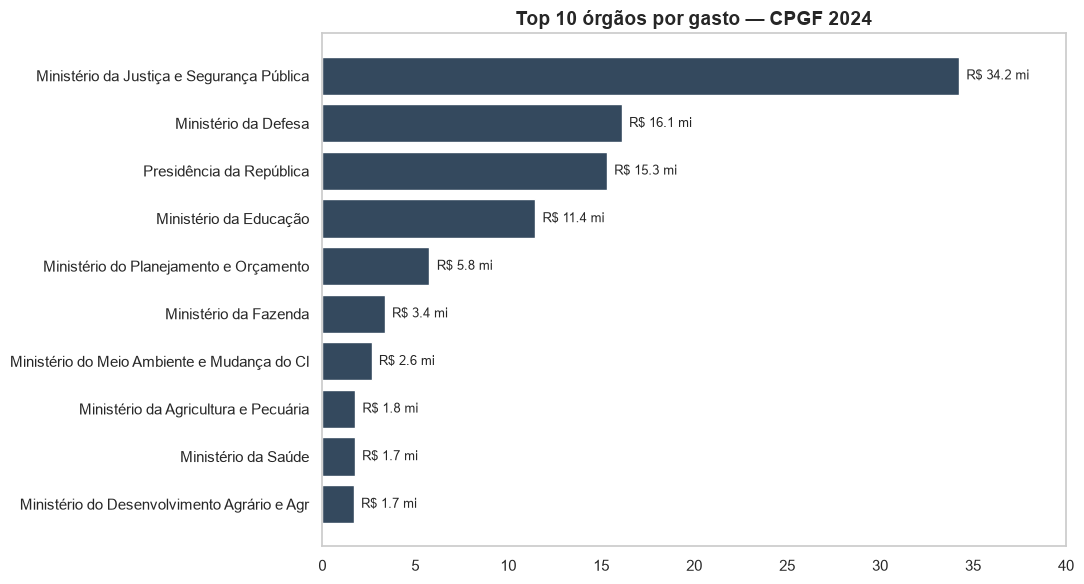

In [16]:
# Gráfico: top 10 órgãos por gasto
dados = (gasto_orgao.sort_values() / 1_000_000)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(dados.index, dados.values, color="#34495E")
ax.grid(False)
ax.set_xlim(0, 40)
ax.set_title("Top 10 órgãos por gasto — CPGF 2024", fontsize=14, weight="bold")

for i, valor in enumerate(dados.values):
    ax.text(valor + 0.4, i, f"R$ {valor:.1f} mi", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/concentracao_orgaos.png", dpi=150, bbox_inches="tight")
plt.show()

*Como ler: cada barra é um órgão, quanto mais longa, maior o gasto no cartão em 2024.*

### Conclusão — Concentração por órgão

Os **10 maiores órgãos** concentram **93,6%** de todo o gasto com cartão corporativo em 2024. O restante do governo federal responde por menos de 7%.

O **Ministério da Justiça e Segurança Pública** lidera isoladamente, com **R$ 34,2 mi**. Mais que o dobro do 2º colocado (Defesa, R$ 16,1 mi) e equivalente a cerca de **34%** de todo o gasto federal no cartão.

Essa concentração é esperada e reflete o perfil dos órgãos, onde Justiça e Defesa têm grande operação de campo, que naturalmente demanda mais uso de cartão.

> **Interpretação:** O cartão corporativo não é um instrumento difuso pela máquina pública — é dominado por poucos órgãos, provavelmente os com maior operação de campo (segurança, defesa). Isso facilita a fiscalização: Com poucos órgãos respondendo por quase todo o gasto, a auditoria pode focar esforço neles e cobrir a maior parte do dinheiro.

## 6. Conclusões e recomendações

**Síntese — o que os dados mostram sobre o cartão corporativo federal em 2024:**

- **Opacidade:** Cerca de 43,9% do gasto (R$ 44,1 milhões) foi em transações sigilosas, cujo tipo não é divulgado. É a 2ª maior categoria, com ticket médio mais que o dobro de uma compra comum.

- **Sazonalidade:** O gasto varia ao longo do ano (de R$ 2,0 mi em fevereiro a R$ 11,0 mi em dezembro). A queda no início do ano não se explica por dias úteis, o padrão aponta para o ciclo orçamentário público.

- **Concentração:** Apenas 10 órgãos respondem por 93,6% de todo o gasto, liderados pelo Ministério da Justiça e Segurança Pública (R$ 34,2 mi). O cartão é dominado por poucos órgãos, não distribuído pela máquina pública.

**Tese final:**

Os dados de 2024 mostram um cartão corporativo que não é o que se imagina. Em vez de uma ferramenta espalhada pela máquina pública para pequenas despesas do dia a dia, ele é concentrado. Poucos órgãos respondem por quase todo o gasto, o uso dispara no fim do ano seguindo o ciclo do orçamento, e o ponto mais sério, quase metade do dinheiro passa por transações sigilosas, de valor alto, fora do alcance de quem quer fiscalizar. A maior parte desse sigilo está justamente onde os valores são maiores na Justiça e Segurança.

**Recomendações / o que investigar a seguir:**

- **Olhar de perto o pico de dezembro.** Vale entender se o salto para R$ 11,0 milhões no último mês é demanda real ou "queima de orçamento", aquela corrida pra gastar o que sobrou antes do ano fechar, pra não perder verba no ano seguinte.

- **Cobrar explicação sobre o gasto sigiloso.** Pedidos via Lei de Acesso à Informação (LAI) sobre as justificativas legais desse sigilo ajudariam a entender o que são esses R$ 44,1 milhões e se o ticket médio alto (o dobro de uma compra comum) bate com operações de segurança ou esconde falha de controle.